=== Distance Matrix (Euclidean) ===
          a         b         c         d         e         f
a  0.000000  0.707107  5.656854  3.605551  4.242641  3.201562
b  0.707107  0.000000  4.949747  2.915476  3.535534  2.500000
c  5.656854  4.949747  0.000000  2.236068  1.414214  2.500000
d  3.605551  2.915476  2.236068  0.000000  1.000000  0.500000
e  4.242641  3.535534  1.414214  1.000000  0.000000  1.118034
f  3.201562  2.500000  2.500000  0.500000  1.118034  0.000000


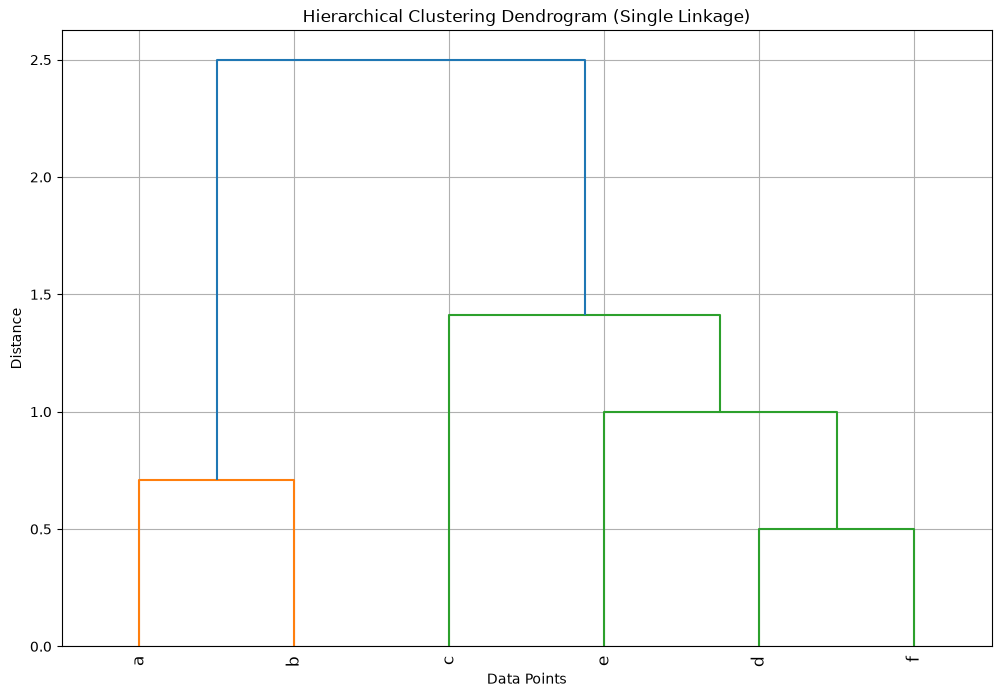

In [2]:
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
# 1. Dataset sederhana
data = np.array([
 [1.0, 1.0], # a
 [1.5, 1.5], # b
 [5.0, 5.0], # c
 [3.0, 4.0], # d
 [4.0, 4.0], # e
 [3.0, 3.5] # f
])
# 2. Hitung Distance Matrix (Euclidean Distance)
distance_matrix = pdist(data, metric='euclidean')
distance_df = pd.DataFrame(squareform(distance_matrix),
 columns=['a', 'b', 'c', 'd', 'e', 'f'],
 index=['a', 'b', 'c', 'd', 'e', 'f'])
# 3. Tampilkan Distance Matrix
print("=== Distance Matrix (Euclidean) ===")
print(distance_df)
# 4. Hierarchical Clustering (Single Linkage)
linked = linkage(data, method='single')
# 5. Plot Dendrogram
plt.figure(figsize=(12, 8))
plt.title("Hierarchical Clustering Dendrogram (Single Linkage)")
dendrogram(linked, labels=['a', 'b', 'c', 'd', 'e', 'f'], leaf_rotation=90)
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

### Penjelasan

Pada cell ini dilakukan seluruh proses awal **Hierarchical Clustering** menggunakan dataset sederhana. Pertama, beberapa library yang dibutuhkan diimpor, yaitu `numpy`, `pandas`, `scipy`, dan `matplotlib`. Selanjutnya dibuat dataset yang terdiri dari enam data, yaitu `a`, `b`, `c`, `d`, `e`, dan `f`, yang masing-masing memiliki dua nilai. Setelah dataset dibuat, dihitung jarak antar data menggunakan **Euclidean Distance** dan hasilnya disusun dalam bentuk **Distance Matrix** agar jarak setiap data dapat dilihat dengan lebih mudah. Kemudian dilakukan proses **Hierarchical Clustering** menggunakan metode **Single Linkage**, yaitu pengelompokan data berdasarkan jarak terdekat antar anggota klaster. Hasil dari proses tersebut selanjutnya digunakan untuk membuat **dendrogram**, yang menampilkan proses penggabungan data secara bertahap berdasarkan nilai jaraknya.


In [4]:
import pandas as pd
df = pd.read_csv("Mall_Customers.csv")
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Penjelasan:

Pada cell ini digunakan library `pandas` untuk membaca dataset **Mall Customers** yang tersimpan dalam file `Mall_Customers.csv`. Fungsi `pd.read_csv()` digunakan untuk memasukkan data ke dalam variabel `df`, kemudian fungsi `df.head()` digunakan untuk menampilkan beberapa baris pertama dari dataset. Tampilan tersebut membantu melihat data awal serta memastikan bahwa dataset berhasil dibaca dan dimuat dengan benar sebelum digunakan pada proses clustering berikutnya.


In [5]:
 x = df.iloc[:, [3, 4]].values

## Penjelasan
Pada cell ini dipilih dua kolom dari dataset df, yaitu Annual Income (k$) dan Spending Score (1-100), yang akan digunakan dalam proses Hierarchical Clustering. Fungsi iloc[:, [3, 4]] digunakan untuk mengambil seluruh baris pada kolom indeks ke-3 dan ke-4, sedangkan .values digunakan untuk mengubah data menjadi array. Kedua fitur tersebut dipilih untuk mengelompokkan pelanggan berdasarkan pendapatan tahunan dan skor pengeluarannya.

In [ ]:

from sklearn.preprocessing import StandardScaler
data_scaler = StandardScaler()
scaled_data = data_scaler.fit_transform(x)
scaled_data.shape


(200, 2)

## Penjelasan
Pada cell ini dilakukan standardisasi data menggunakan StandardScaler agar nilai pada fitur Annual Income dan Spending Score memiliki skala yang lebih seimbang sebelum digunakan dalam proses clustering. StandardScaler() digunakan untuk membuat objek standardisasi, sedangkan fit_transform(x) digunakan untuk mempelajari nilai dari data sekaligus mengubahnya ke dalam bentuk data yang sudah distandardisasi. Hasil standardisasi kemudian disimpan dalam variabel scaled_data. Terakhir, scaled_data.shape digunakan untuk mengetahui ukuran data setelah proses standardisasi, yaitu jumlah data dan jumlah fitur yang digunakan. Pada dataset ini terdapat 200 data pelanggan dengan 2 fitur, sehingga bentuk data yang dihasilkan adalah (200, 2).

In [ ]:

from scipy.cluster.hierarchy import linkage, dendrogram
clustering = linkage(scaled_data, method="complete", metric="euclidean")

## Penjelasan
Pada cell ini dilakukan proses Hierarchical Clustering menggunakan data yang telah distandardisasi pada scaled_data. Library linkage digunakan untuk menentukan bagaimana data akan digabungkan secara bertahap menjadi beberapa klaster. Pada percobaan ini digunakan metode Complete Linkage, yaitu penggabungan klaster berdasarkan jarak terjauh antara anggota dari dua klaster. Parameter metric="euclidean" menunjukkan bahwa perhitungan jarak antar data menggunakan Euclidean Distance. Hasil dari proses clustering disimpan dalam variabel clustering, yang nantinya digunakan untuk membuat dendrogram sehingga proses pengelompokan data pelanggan dapat dilihat dalam bentuk grafik.

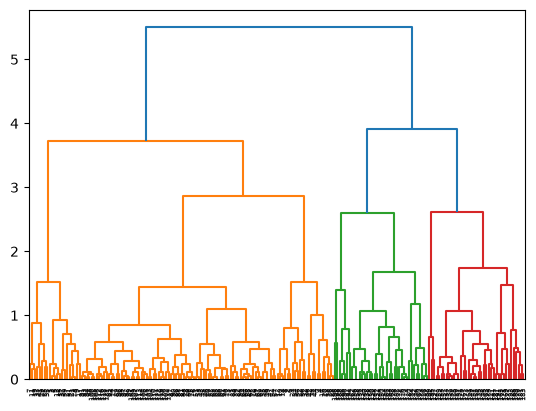

In [ ]:

import matplotlib.pyplot as plt
dendrogram(clustering)
plt.show()


## Penjelasan
Pada cell ini digunakan matplotlib.pyplot untuk menampilkan hasil proses Hierarchical Clustering dalam bentuk dendrogram. Fungsi dendrogram(clustering) menggunakan hasil clustering yang telah disimpan pada variabel clustering untuk menggambarkan proses penggabungan data secara bertahap. Kemudian plt.show() digunakan untuk menampilkan grafik tersebut. Dendrogram ini dapat digunakan untuk melihat hubungan antar pelanggan dan menentukan pembentukan kelompok berdasarkan jarak penggabungannya.

## Tugas
Pada percobaan pertama dengan dataset sederhana, bandingkan hasil plot dendrogram single linkage dengan complete linkage
dan average linkage

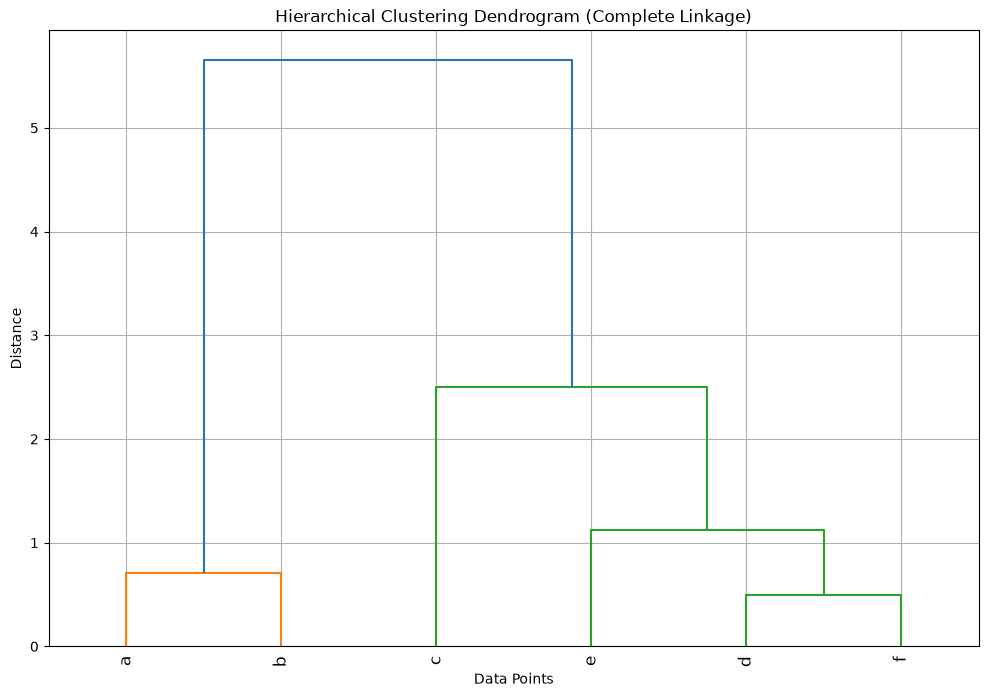

In [ ]:
## 1. Complete Linkage

# Hierarchical Clustering (Complete Linkage)
linked_complete = linkage(data, method='complete')

# Plot Dendrogram
plt.figure(figsize=(12, 8))
plt.title("Hierarchical Clustering Dendrogram (Complete Linkage)")
dendrogram(linked_complete, labels=['a', 'b', 'c', 'd', 'e', 'f'], leaf_rotation=90)
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

## Penjelasan
Pada cell ini dilakukan Hierarchical Clustering menggunakan metode Complete Linkage pada dataset sederhana yang sama. Berbeda dengan Single Linkage yang menggunakan jarak terdekat, Complete Linkage menentukan penggabungan klaster berdasarkan jarak terjauh antar data dalam dua klaster. Hasil clustering kemudian ditampilkan dalam bentuk dendrogram untuk melihat proses penggabungan data dan perubahan jarak pada setiap tahapnya.

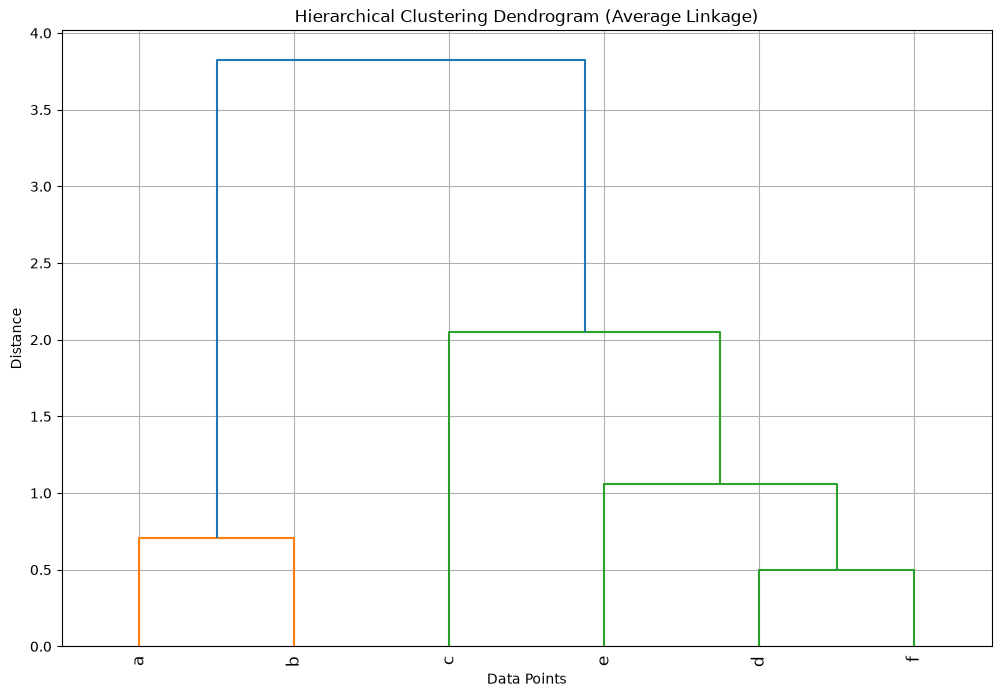

In [13]:
## 2. Average Linkage
# Hierarchical Clustering (Average Linkage)
linked_average = linkage(data, method='average')

# Plot Dendrogram
plt.figure(figsize=(12, 8))
plt.title("Hierarchical Clustering Dendrogram (Average Linkage)")
dendrogram(linked_average, labels=['a', 'b', 'c', 'd', 'e', 'f'], leaf_rotation=90)
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

## Penjelasan
Pada cell ini dilakukan Hierarchical Clustering menggunakan metode Average Linkage. Metode ini menentukan jarak antar klaster berdasarkan rata-rata jarak antara anggota dari dua klaster. Dengan metode ini, proses penggabungan tidak hanya mempertimbangkan satu pasangan data yang paling dekat atau paling jauh, tetapi menggunakan nilai rata-rata jarak dari seluruh anggota klaster. Hasil pengelompokan kemudian ditampilkan menggunakan dendrogram untuk melihat proses penggabungan data secara bertahap berdasarkan jaraknya. Hasil dendrogram ini selanjutnya dapat dibandingkan dengan Single Linkage dan Complete Linkage untuk melihat perbedaan pola pengelompokan yang dihasilkan oleh masing-masing metode.

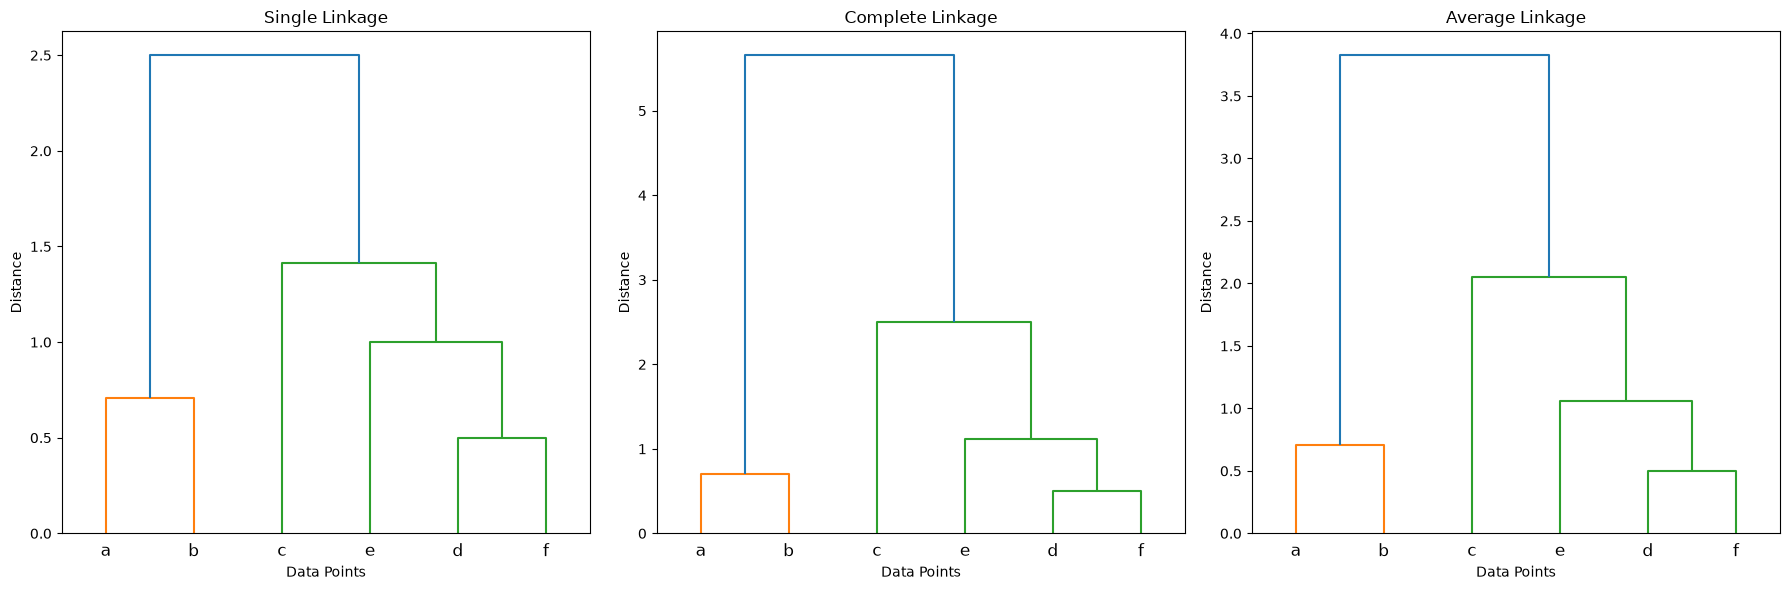

In [14]:
## 3. Perbandingan Ketiga Dendrogram
plt.figure(figsize=(18, 6))

# Single Linkage
plt.subplot(1, 3, 1)
dendrogram(linked, labels=['a', 'b', 'c', 'd', 'e', 'f'])
plt.title("Single Linkage")
plt.xlabel("Data Points")
plt.ylabel("Distance")

# Complete Linkage
plt.subplot(1, 3, 2)
dendrogram(linked_complete, labels=['a', 'b', 'c', 'd', 'e', 'f'])
plt.title("Complete Linkage")
plt.xlabel("Data Points")
plt.ylabel("Distance")

# Average Linkage
plt.subplot(1, 3, 3)
dendrogram(linked_average, labels=['a', 'b', 'c', 'd', 'e', 'f'])
plt.title("Average Linkage")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.tight_layout()
plt.show()

## Penjelasan
Pada cell ini dibandingkan hasil dendrogram dari tiga metode Hierarchical Clustering, yaitu Single Linkage, Complete Linkage, dan Average Linkage. Ketiga metode menggunakan dataset dan jarak yang sama, tetapi memiliki cara yang berbeda dalam menentukan jarak antar klaster. Single Linkage menggunakan jarak terdekat, Complete Linkage menggunakan jarak terjauh, sedangkan Average Linkage menggunakan rata-rata jarak antar anggota klaster. Perbedaan cara menentukan jarak tersebut menyebabkan urutan dan ketinggian penggabungan pada dendrogram dapat berbeda. Jadi, dendrogram dapat digunakan untuk melihat bagaimana masing-masing metode menghasilkan proses pengelompokan data yang berbeda.

## Kesimpulan
Berdasarkan hasil perbandingan, ketiga metode menghasilkan dendrogram dengan pola pengelompokan yang berbeda. Single Linkage menggabungkan klaster berdasarkan jarak terdekat sehingga lebih mudah membentuk pengelompokan melalui data yang saling berdekatan. Complete Linkage menggunakan jarak terjauh sehingga penggabungan klaster cenderung membutuhkan jarak yang lebih besar. Sementara itu, Average Linkage menggunakan rata-rata jarak antar anggota klaster sehingga hasilnya berada di antara karakteristik Single Linkage dan Complete Linkage. Perbedaan tersebut dapat dilihat dari posisi dan jarak pada masing-masing dendrogram.